# How to use the DCCLab Python module : A guide to image analysis


## Introduction
Image analysis occupy a very important role in science. In recent years, lots of new methods were developped to help us with this often huge and time consuming task. This is why we thougth it would be a great idea to create a Python module that regroup some of the most common methods used when handling images. `dcclab` is a user-oriented module developped by Danel Côté's DCCLab group. The main purpose of this module is to regroup image analysis methods at the same place, without having to use a quadrillion of different packages or file readers.

Disclaimer : The following tutorial is not exhaustive of everything the module can do. `dcclab` is still a work in progress and major parts of it may change in the future.

## Reading a file
Probably the most basic action to do in image processing. There is A LOT of image files existing around the globe. Some of them are convenient for upload/download purpose because of their compression, while others are quite heavy and contain a lot of untouched data. A the moment these lines were written, `dcclab` can read most common files such as `.png` or `.jpg`. It can also read fancier stuff like Carl Zeiss Microscopy Files (`.czi`), Tagged Image File Format (`.tif`, `.tiff`) and Leica Image File Format (`.lif`). For the first part of this tutorial, let's first of all import the essential packages:

In [148]:
import dcclab as dcc # There it is, the dcclab module
import os # Easier to handle paths with this one
import numpy as np # For matrix handling and computations
import cv2 as cv # For later

Now, we can read files with `dcclab`. Let's open a `.czi` file:

In [149]:
path = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "tests", "testData", "testCziFile.czi")
czi = dcc.Image(path=path) # We use the Image class form dcclab to read

The `Image` class gives us an instance of `Image` and with this object we can do some basic handling:

## Working with channels instead of whole images

In [150]:
czi.sizeInBytes

11306240

In [151]:
czi.shape

(1936, 1460, 2)

We can see that when we call `shape`, we get the shape of the matrix containing our pixels. In this example, we have a file with 2 channels (the last element of the tuple), a height of 1460 pixels and a width of 1936 pixels. Knowing this, we can work on single channel if we want.

Why can we work with single channel? Because we did the module with the fact that an image is composed of X number of channels (most of the time it is 3 channels, like `.jpg` files, but `.png` can handle 4 channels. The 4th channel is the trasparency of the image). With this in mind, an `Image` object is composed of some `Channel` objects, which are the basis of our module. Most of the computation is done on single `Channel`. Let's work with our two channels, but separated:

In [152]:
firstChannel = czi[0] # We can access a single with indexing
secondChannel = czi[1]

Let's display them:

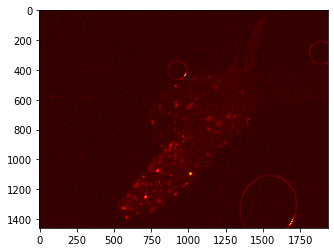

In [153]:
_=firstChannel.display(colorMap="hot") # We can specify the color map. It is 'jet' by default

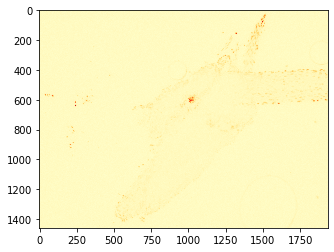

In [154]:
_=secondChannel.display(colorMap="YlOrRd")

"Can we display both of them on the same display?" Sure!

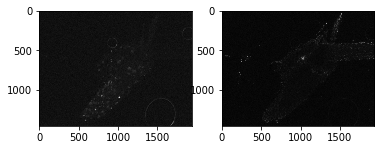

In [155]:
_=dcc.Channel.multiChannelDisplay([firstChannel, secondChannel], ["gray"])

`multiChannelDisplay` is a static method from the `Channel` class, this is why it doesn't need a specific instance of `Channel` in order to work. It takes 2 arguments : The first one is a list of `Channel` instances, while the second one is a list of color maps. It is important to remember that the list of color maps is optional, but when given, it must either have only one element (applied to every channel) or have as element as there are channels.

## It's quite nice to display channels, but can we do something more *useful*?
**YES YOU CAN**! The purpose of `dcclab` is not just about displaying stuff... there is a ton of apps that do just that! `Channel` class offers a lot of methods varying from global entropy of the channel to spectral filtering and Fourier transform. Let's start with some basic high school maths on our channels:

In [156]:
firstChannel.getAverageValueOfPixels() # Computes the average value of the pixels

133.27654640269444

In [157]:
secondChannel.getMedian() # Computes the median

75.0

In [158]:
firstChannel.getExtrema() # Finds the minimum and the maximum values of the channel

(64, 1047)

In [159]:
secondChannel.getMaximum() # Finds the (X, Y) position of pixels with the maximum intensity

[(1837, 608)]

There are a few more methods that can be used to extract basic stats about a single channel, it is left to the reader to try them out! Let's move on to heavier stuff: let's compute the histogram!

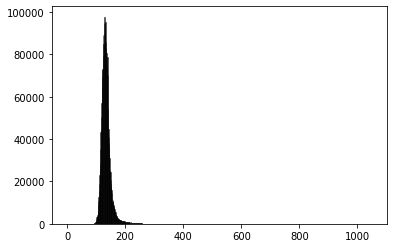

In [160]:
_=firstChannel.displayHistogram() # Displays the histogram of the channel

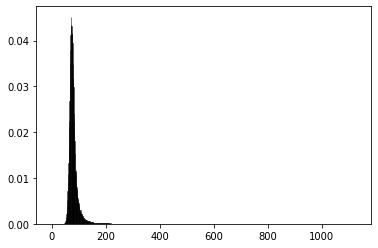

In [161]:
_=secondChannel.displayHistogram(normed=True) # Displays the normalized histogram of the channel (the sum gives 1)

There is another method, called `getHistogramValues()` which only computes the values and doesn't display the whole histogram. It can be used for various reasons, such as thresholding techniques or histogram equalization.

## But can we do more *intense* stuff?
Again, **YES YOU CAN**! Like I said earlier, histograms are useful when we want to apply thresholding techniques, such as Otsu's method or isodata thresholding. These two methods are part of the module, as well as other thresholding methods such as global thresholding (with an arbitrary value) or local/adaptive thresholding. Let's take a look at some of them:

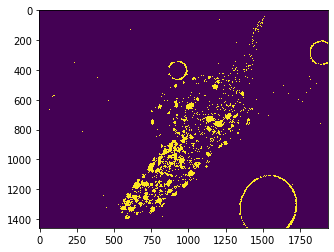

In [162]:
thresholdOtsu = firstChannel.getOtsuThresholding() # Thresholds the original channel according to Otsu's methods
#and returns a new one
_=thresholdOtsu.display()

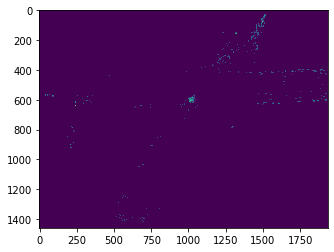

In [163]:
thresholdGlobal = secondChannel.getGlobalThresholding(201) # Thresholds the original array with according to a given value
_=thresholdGlobal.display()

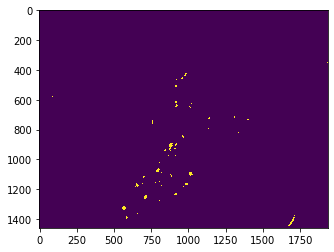

In [164]:
adaptiveMean = firstChannel.getAdaptiveThresholdMean(59) # Localy threshold the original channel with a kernel. The size
# of the kernel is given by the sole parameter of this method. The size must be odd
_=adaptiveMean.display()

Thresholding an image is the most basic way to segment it. But in order to get a good segmentation, the image needs to be "clean", to not have a lot of noise. Let's continue with some simulated images of circles representing cells.

In [165]:
def generateCircles(arrayShape:tuple, nbCircles:int, radiusAvg:float, radiusStdDev:float) -> np.ndarray:
    array = np.zeros(arrayShape)
    radii = []
    positions = set()
    while len(positions) < nbCircles:
        tempRadius = np.random.normal(radiusAvg, radiusStdDev)
        tempsRadius = abs(np.ceil(tempRadius))
        tempX = np.random.choice(range(arrayShape[1] + 1))
        tempY = np.random.choice(range(arrayShape[0] + 1))
        positions.add((tempX, tempY))
        radii.append(tempRadius)
    for i in range(nbCircles):
        cv.circle(array, positions.pop(), int(radii[-(i+1)]), 1, -2)
    return array

In [166]:
simulation = generateCircles((1000, 1000), 100, 5.8, 2.3)

Now let's create an `Image` instance with that simulated array.

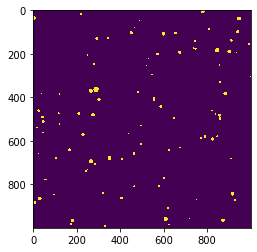

In [167]:
simulatedImage = dcc.Image(simulation)
simulatedImage.display()

In [168]:
simulatedChannel = simulatedImage[0]

We can apply some noise to the channel with two methods from the `Channel` class.

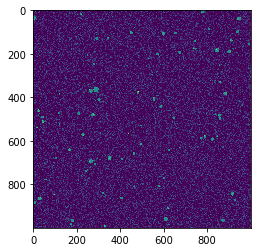

In [169]:
noisySimulatedChannel = simulatedChannel.applyGaussianNoise(sigma=0.3, mean=0)
_=noisySimulatedChannel.display()

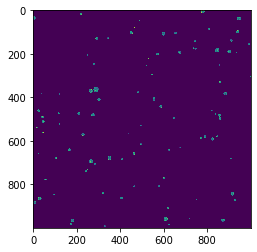

In [170]:
noisySimulatedChannel2 = simulatedChannel.applyPoissonNoise(10)
_=noisySimulatedChannel2.display()

Let's denoise `noisySimulatedChannel` with different algorithms.

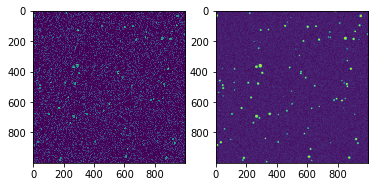

In [171]:
gaussianFilter = noisySimulatedChannel.getGaussianFilter(sigma=2)
_=dcc.Channel.multiChannelDisplay([noisySimulatedChannel, gaussianFilter])

We can see that it is better, but can be improved. Let's try with another value of standard deviation:

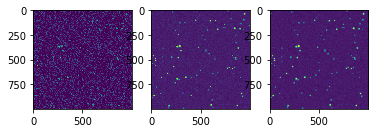

In [172]:
gaussianFilter2 = noisySimulatedChannel.getGaussianFilter(3)
_=dcc.Channel.multiChannelDisplay([noisySimulatedChannel, gaussianFilter, gaussianFilter2])

It is better, but we can see that we lost some precision with the edges of the circles. Gaussian filter (also known as gaussian blur) is good when there is not too much noise. Our previous example was quite noisy. Let's try with less noise:

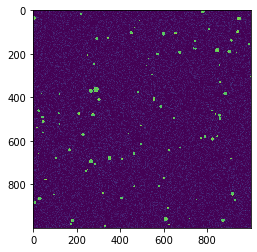

In [173]:
lessNoisySimulatedChannel = simulatedChannel.applyGaussianNoise(sigma=0.08, mean=0)
_=lessNoisySimulatedChannel.display()

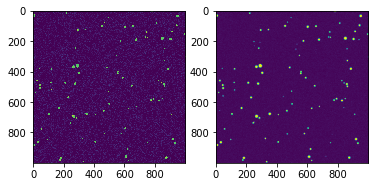

In [174]:
gaussianFilterLessNoise = lessNoisySimulatedChannel.getGaussianFilter(2)
_=dcc.Channel.multiChannelDisplay([lessNoisySimulatedChannel, gaussianFilterLessNoise])

Wow! It looks really good. But can we denoise images with other algorithms? Sure. We can use morphological methods. Let's see them in action with our very noisy channel. First of all, let's use morphological opening. This algorithm removes white noise by applying some kind of filter. The size of the filter matters because it specify what is the maximum size of the grains we want to remove. Opening is the inverse of closing, which removes small black holes by filling them. It is usefull to fill components.

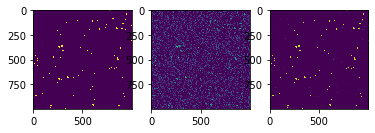

In [175]:
openingFilter = noisySimulatedChannel.getOpening()
_=dcc.Channel.multiChannelDisplay([simulatedChannel, noisySimulatedChannel, openingFilter])

We can then try erosion. It is another morphological algorithm, but simpler than opening/closing (opening is the dilation of the erosion, while closing is the erosion of dilation). Erosion shrinks bright regions and enlarges dark regions, while dilation does the inverse.

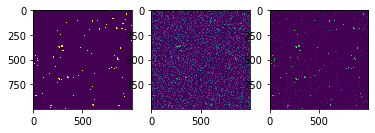

In [176]:
erosionFilter = noisySimulatedChannel.getErosion()
_=dcc.Channel.multiChannelDisplay([simulatedChannel, noisySimulatedChannel, erosionFilter])

It is not so bad, but worse than the opening. Like I said, opening uses dilation after erosion, so it first of all removes white noise and shrinks the other components but then dilation enlarges those shrinked components. That's why we get better results by applying opening.

There are also other filters that we can use. In fact, there exist as many filters as we want. You can build your own filter if you want! The fundamental principle behind filtering is convolution (or Fourier transform, but that will come later. Also, don't panic if you've never heard about convolution. If you read about it and doesn't understand anything, it's ok. I didn't understand it either until I applied it to image analysis... a few months ago... more than a year after I heard about it for the first time...). Convolution is quite simple when we apply it to images. Just think about it this way: take your grayscale image (which is a $N\times M$ matrix) and take another smaller matrix (which is preferably square and with odd height & width. Let's take a $C\times C$ matrix with $C \leq N \land C\leq M$). Then, you slide the smaller matrix (the kernel/window) over the image and apply some mathematical equation. See the gif below (taken from https://towardsdatascience.com/intuitively-understanding-convolutions-for-deep-learning-1f6f42faee1)
![Alt Text](https://miro.medium.com/max/700/1*Fw-ehcNBR9byHtho-Rxbtw.gif)

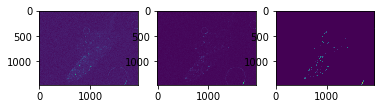

In [177]:
stdDevFilter = firstChannel.getStandardDeviationFilter(5) # Slides a small window which size is specified as parameter.
# This filter computes the local standard deviation of the element "under" the window. 
entropyFilter = firstChannel.getEntropyFilter(7) # Same thing as the std deviation filter, but computes local entropy
_=dcc.Channel.multiChannelDisplay([firstChannel, stdDevFilter, entropyFilter])

There is also a special part in our hearts for edge detection filters/algorithms. These are really useful in machine learning for feature extraction and other things (line detection for self-driven cars or robots, etc). `dcclab` contains 2 edge detection filters (not counting the Hough transform, more info to come) : the Canny edge detection filter and the Sobel filter. The latter is simple, it is just the convolution of the original channel with two simple matrices (one for horizontal lines, the other for vertical lines). The Canny filter is more complex, because it uses a filter based on the derivative of a Gaussian and hysterisis thresholding.

To demonstrate the power of the Sobel and the Canny filters, let's create antother simulation. Let's create oblique lines (which can be compared to fiber-like structures).

In [178]:
def fiberLikeStructures(arrayShape:tuple, avgLength:float, stdDevLength:float, avgThickness:float, stdDevThickness:float,
                       avgSpacing:float, stdDevSpacing:float, nbLines:int) -> np.ndarray:
    spacings = np.abs(np.random.normal(avgSpacing, stdDevSpacing, nbLines)).astype(np.uint16)
    startingX = np.round(np.cumsum(np.zeros((nbLines,)) + spacings)).astype(np.uint16)
    startingY = np.abs(np.random.normal(arrayShape[0] // 8, arrayShape[0] // 16, nbLines)).astype(np.uint16)
    startingPoints = zip(startingX, startingY)
    lengths = np.abs(np.random.normal(avgLength, stdDevLength, nbLines)).astype(np.uint16)
    thicknesses = np.ceil(np.abs(np.random.normal(avgThickness, stdDevThickness, nbLines))).astype(np.uint8)
    angles = np.random.choice(np.arange(92 / 180 * np.pi, 98 / 180 * np.pi, 0.005),
                              nbLines)
    finishingPosX = (np.cos(angles) * lengths).astype(int) + startingX
    finishingPosY = (np.sin(angles) * lengths).astype(int) + startingY
    finishingPoints = zip(finishingPosX, finishingPosY)
    array = np.zeros(arrayShape)
    for initialPoints, finalPoints, thickness in zip(startingPoints, finishingPoints, thicknesses):
        cv.line(array, initialPoints, finalPoints, 1, thickness)

    return array

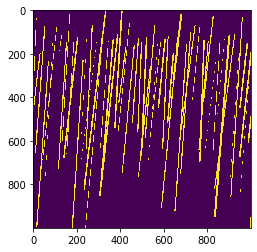

In [179]:
simulatedFibers = fiberLikeStructures((1000, 1000), 600, 200, 3, 2, 20, 3, 70)
simulatedFibersImage = dcc.Image(simulatedFibers)
simulatedFibersImage.display()

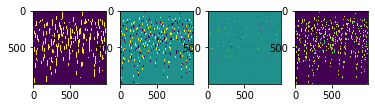

In [180]:
simulatedFibersChannel = simulatedFibersImage[0]
sobelHFilter = simulatedFibersChannel.getHorizontalSobelFilter()
sobelVFilter = simulatedFibersChannel.getVerticalSobelFilter()
sobelBoth = simulatedFibersChannel.getSobelFilter()
_=dcc.Channel.multiChannelDisplay([simulatedFibersChannel, sobelHFilter, sobelVFilter, sobelBoth])

In [181]:
#TODO add Canny when on master

Two last interesting filters : the x and y derivative filters. They kind of act like edge detection filters, because edges are significant contrast difference between two regions and significant contrast means a high derivative value. Let's compare them with the other filters.

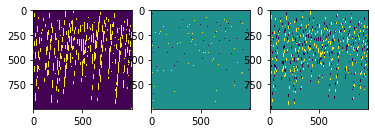

In [183]:
xDerivative = simulatedFibersChannel.getXAxisDerivative()
yDerivative = simulatedFibersChannel.getYAxisDerivative()
_=dcc.Channel.multiChannelDisplay([simulatedFibersChannel, xDerivative, yDerivative])

compare sobel kernel with x/y axis derivatives